In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [14]:

# Параметры робота
robot_mass = 5.0  # Масса робота (кг)
wheel_radius = 0.1  # Радиус колеса (м)
robot_width = 0.5  # Ширина робота (м)
g = 9.81  # Ускорение свободного падения (м/с^2)
dt = 0.1  # Шаг времени (с)

# Заданные параметры движения
linear_speed = 0.3  # Линейная скорость робота (м/с)
arc_radius = 1.0  # Радиус дуги (м)
arc_angle = np.pi  # Угол дуги (180 градусов)
line_length = 2.0  # Длина прямолинейного участка (м)

# Массивы для хранения результатов
x_positions = []
y_positions = []
psi_angles = []
torque_left_wheel = []
torque_right_wheel = []

# Начальные условия
x, y, psi = 0.0, 0.0, 0.0  # Начальная позиция и угол ориентации


In [15]:
# 1. Прямолинейный участок
line_time = line_length / linear_speed
num_steps_line = int(line_time / dt)
for _ in range(num_steps_line):
    x += linear_speed * np.cos(psi) * dt
    y += linear_speed * np.sin(psi) * dt
    torque_left = robot_mass * g * (linear_speed / wheel_radius)
    torque_right = robot_mass * g * (linear_speed / wheel_radius)
    torque_left_wheel.append(torque_left)
    torque_right_wheel.append(torque_right)
    psi_angles.append(psi)
    x_positions.append(x)
    y_positions.append(y)

In [16]:
# 2. Дуга (поворот с центром, развернутая на 90 градусов)
arc_time = (arc_angle * arc_radius) / linear_speed
num_steps_arc = int(arc_time / dt)
angular_speed = linear_speed / arc_radius

# Центр вращения дуги (разворот на 90 градусов)
x_center = x + arc_radius * np.cos(psi)
y_center = y + arc_radius * np.sin(psi)

for _ in range(num_steps_arc):
    psi += angular_speed * dt
    x = x_center - arc_radius * np.cos(psi)
    y = y_center - arc_radius * np.sin(psi)
    torque_left = robot_mass * g * ((linear_speed - angular_speed * robot_width / 2) / wheel_radius)
    torque_right = robot_mass * g * ((linear_speed + angular_speed * robot_width / 2) / wheel_radius)
    torque_left_wheel.append(torque_left)
    torque_right_wheel.append(torque_right)
    psi_angles.append(psi)
    x_positions.append(x)
    y_positions.append(y)


In [17]:
# Преобразование данных в DataFrame
results = pd.DataFrame({
    "X (m)": x_positions,
    "Y (m)": y_positions,
    "Psi (rad)": psi_angles,
    "Torque Left (Nm)": torque_left_wheel,
    "Torque Right (Nm)": torque_right_wheel
})


In [18]:
print("Результаты моделирования:")
display(results)

Результаты моделирования:


,X (m),Y (m),Psi (rad),Torque Left (Nm),Torque Right (Nm)
0,0.030000,0.000000,0.00,147.1500,147.1500
1,0.060000,0.000000,0.00,147.1500,147.1500
2,0.090000,0.000000,0.00,147.1500,147.1500
3,0.120000,0.000000,0.00,147.1500,147.1500
4,0.150000,0.000000,0.00,147.1500,147.1500
...,...,...,...,...,...
165,3.969992,-0.141120,3.00,110.3625,183.9375
166,3.973780,-0.111361,3.03,110.3625,183.9375
167,3.976673,-0.081502,3.06,110.3625,183.9375
168,3.978669,-0.051570,3.09,110.3625,183.9375


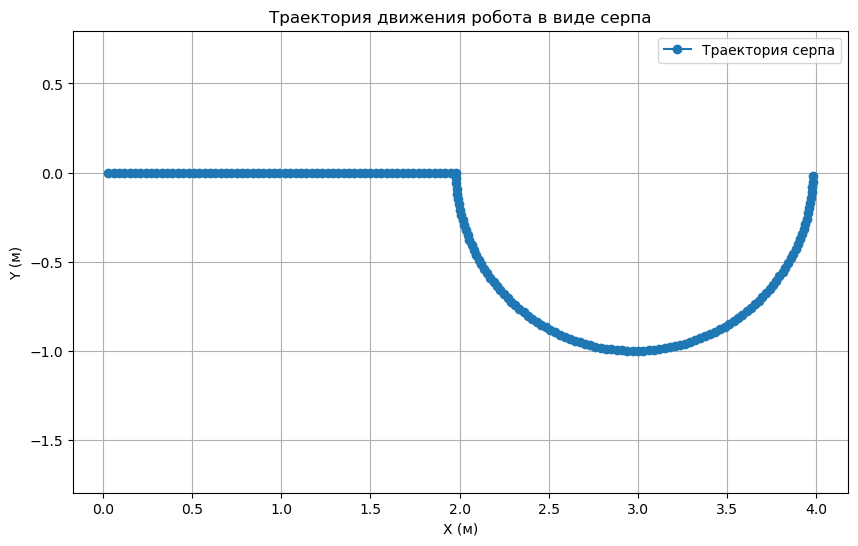

In [19]:
# Построение траектории серпа
plt.figure(figsize=(10, 6))
plt.plot(x_positions, y_positions, label="Траектория серпа", marker='o')
plt.title("Траектория движения робота в виде серпа")
plt.xlabel("X (м)")
plt.ylabel("Y (м)")
plt.legend()
plt.axis('equal')
plt.grid()
plt.show()

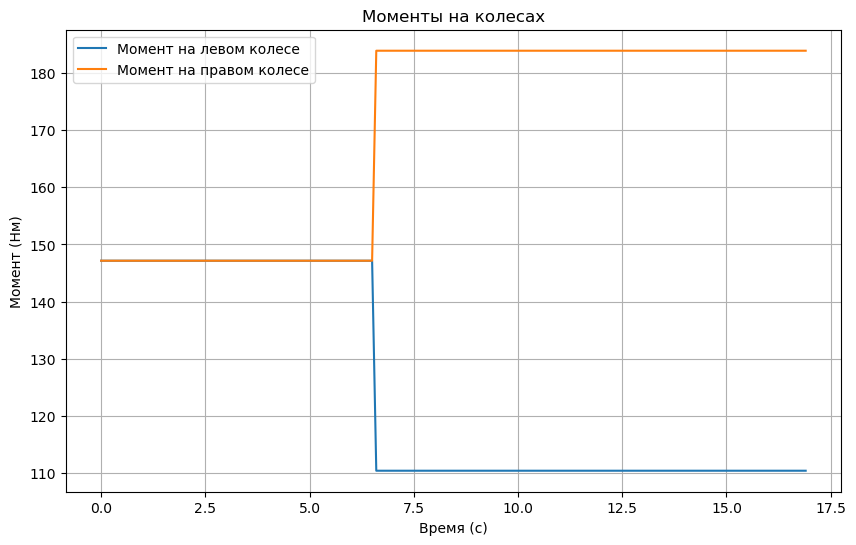

In [20]:
# Построение моментов на колесах
plt.figure(figsize=(10, 6))
plt.plot(results.index * dt, results["Torque Left (Nm)"], label="Момент на левом колесе", linestyle='-')
plt.plot(results.index * dt, results["Torque Right (Nm)"], label="Момент на правом колесе", linestyle='-')
plt.title("Моменты на колесах")
plt.xlabel("Время (с)")
plt.ylabel("Момент (Нм)")
plt.legend()
plt.grid()
plt.show()

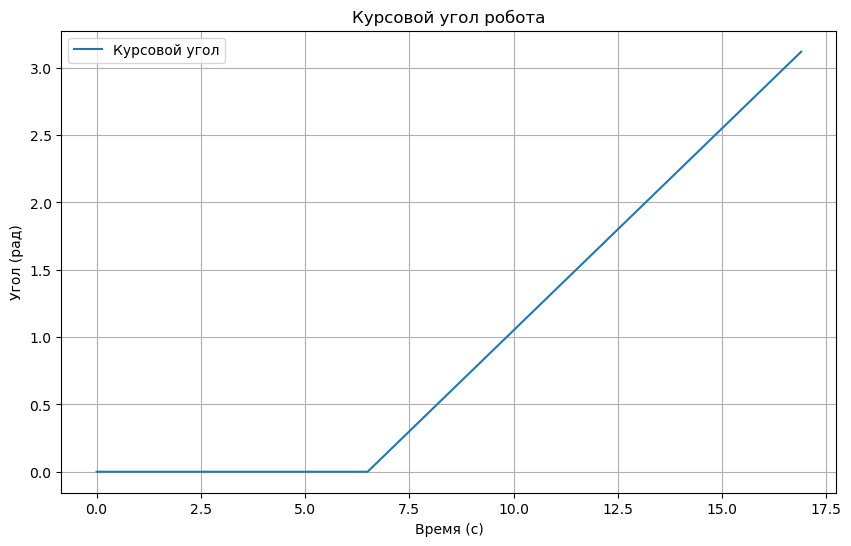

In [21]:
# Построение курсового угла
plt.figure(figsize=(10, 6))
plt.plot(results.index * dt, results["Psi (rad)"], label="Курсовой угол", linestyle='-')
plt.title("Курсовой угол робота")
plt.xlabel("Время (с)")
plt.ylabel("Угол (рад)")
plt.legend()
plt.grid()
plt.show()